# CONFIG

In [9]:
import os
import pandas as pd
import numpy as np
import cv2

from maikol_utils.print_utils import print_separator
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from src.config.config import Configuration

CONFIG = Configuration()

# CODE

## Data

In [11]:
from maikol_utils.file_utils import list_dir_files

rng = np.random.default_rng(CONFIG.seed)

files, n = list_dir_files(CONFIG.all_path, recursive=True)
print(f"Found {n} files in {CONFIG.all_path}")

Found 6899 files in data/NaturalImages/all


## Load trained model

In [12]:
from src.model import RowleyFaceNN, FaceCNN
from src.model import FaceDetectionModule, FaceDataModule

print("Loading:", CONFIG.best_cnn_model_path)

# path = CONFIG.best_cnn_model_path
path = os.path.join(CONFIG.MODELS_PATH, "best_cnn_model-9695.ckpt")
loaded_module = FaceDetectionModule.load_from_checkpoint(
    path,
    CONFIG=CONFIG,
    model=FaceCNN(
        in_channels=1 if CONFIG.gray_scale else 3,
        num_classes=1,
    ),
)
loaded_module.eval()
print("Model loaded successfully.")

Loading: models/best_cnn_model.ckpt
Model loaded successfully.


In [13]:
def draw_boxes(img, faces):
    for (x, y, w, h) in faces:
        # img, pt1, pt2, color (BGR), thickness
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 1)
    return img

def show_crops(crops_to_show):
    n = len(crops_to_show)
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, crop in zip(axes, crops_to_show):
        # grayscale (2D) — show directly; BGR (3D uint8) — convert to RGB
        if crop.ndim == 2:
            ax.imshow(crop, cmap="gray")
        else:
            crop_show = crop
            if crop.dtype != np.uint8:
                crop_show = np.clip(crop, 0, 255).astype(np.uint8)
            ax.imshow(cv2.cvtColor(crop_show, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    for ax in axes[len(crops_to_show):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [20]:
import time
import torch
import torchvision.transforms as transforms
from PIL import Image

from src.data import local_normalize_image
from src.data import get_all_image_crops

path = "data/WIDER_train/img_test/0_Parade_marchingband_1_446.jpg"

image = cv2.imread(path, cv2.IMREAD_GRAYSCALE if CONFIG.gray_scale else cv2.IMREAD_COLOR)
t1 = time.time()
# img = local_normalize_image(CONFIG, image)
t2 = time.time()
# crops = get_all_image_crops(CONFIG, img=img)
crops = get_all_image_crops(CONFIG, img=image)
t3 = time.time()

# crops = [{**crop, 'img': ((crop['img'] - 3) / (6) * 255).astype(np.uint8)} for crop in crops]


print(f"Generated {len(crops):_} crops from the image.")

to_tensor = transforms.ToTensor()
tensors = [to_tensor(Image.fromarray(crop['img'])) for crop in crops]

all_probs = []
device = next(loaded_module.parameters()).device
for i in range(0, len(crops), CONFIG.batch_size):
    batch_tensors = torch.stack(tensors[i:i+CONFIG.batch_size]).to(device)
    with torch.no_grad():
        logits = loaded_module(batch_tensors).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)

probs = np.array(all_probs)
preds = (probs > 0.7).astype(int)  

faces = [(crop['x'], crop['y'], crop['w'], crop['h']) for crop, pred in zip(crops, preds) if pred == 1]
boxes = draw_boxes(image.copy(), faces)

t4 = time.time()

print(f"Time taken for normalization: {t2 - t1:.2f} seconds")
print(f"Time taken for crop generation: {t3 - t2:.2f} seconds")
print(f"Time taken for inference: {t4 - t3:.2f} seconds")


cv2.imshow('Face Detection Result', boxes)
cv2.waitKey(0) 
cv2.destroyAllWindows()

Generated 20_889 crops from the image.
Time taken for normalization: 0.00 seconds
Time taken for crop generation: 0.04 seconds
Time taken for inference: 1.28 seconds


In [15]:
print(len([crop['img'] for crop, pred in zip(crops, preds) if pred == 1]))
print(len([crop['img'] for crop, pred in zip(crops, preds) if pred == 0]))

6604
14285


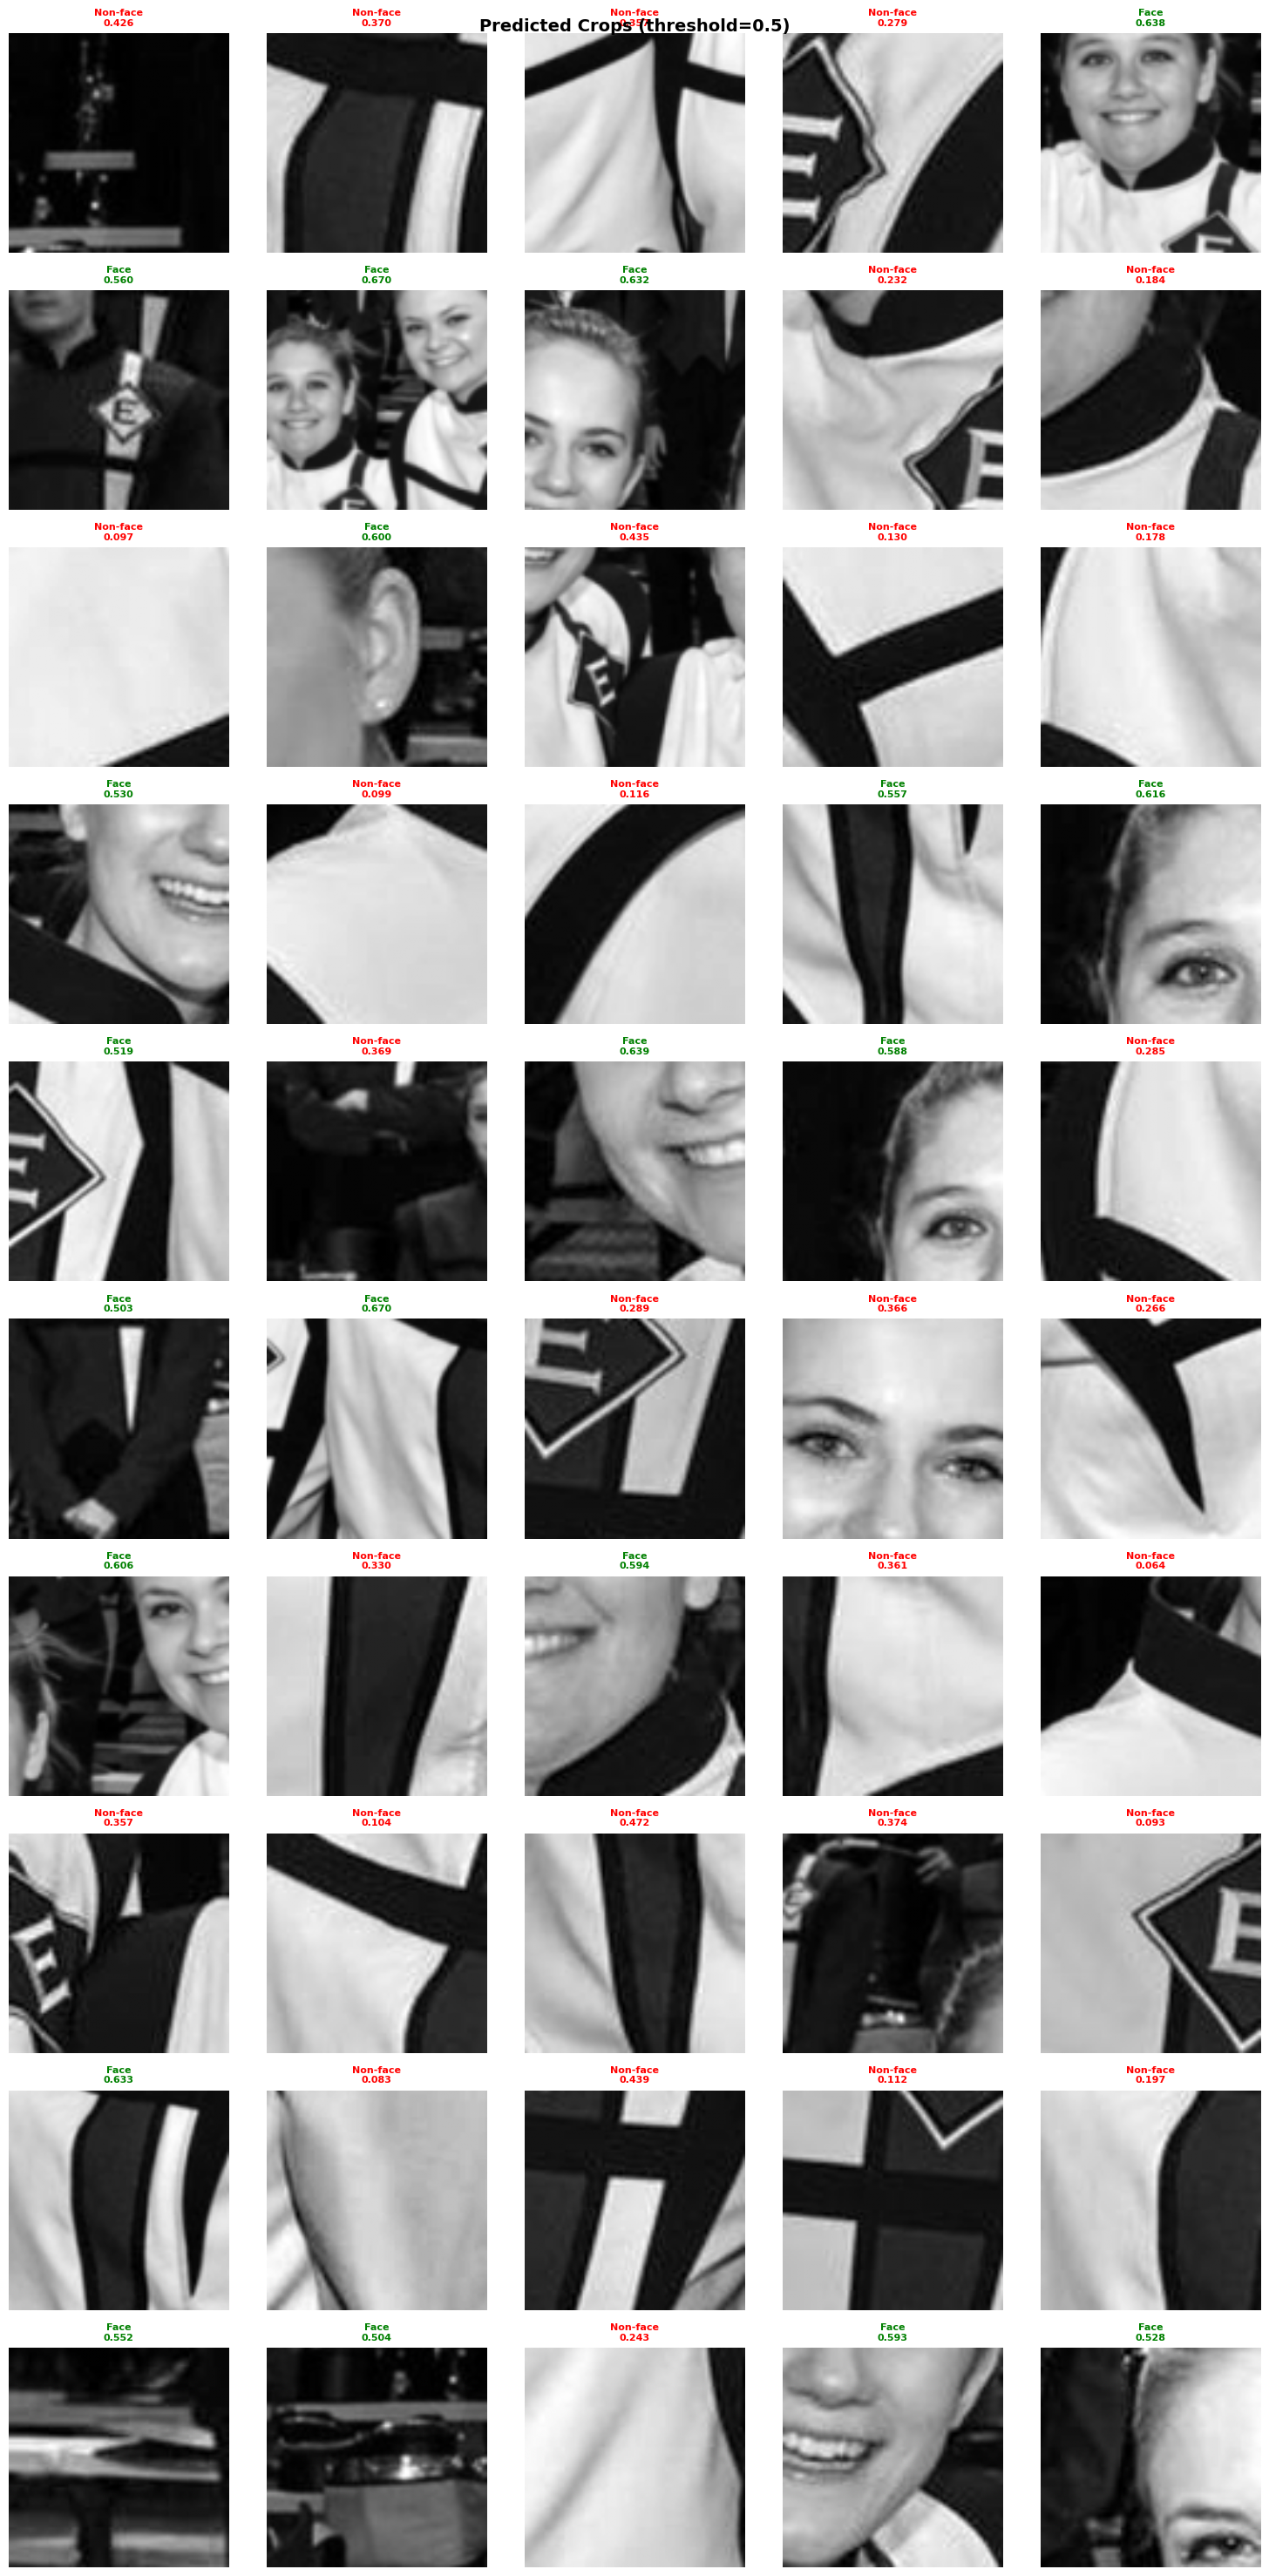

In [16]:
# show some predicted crops
n_crops = min(50, len(crops))  # 5x10 grid = 50 crops
cols = 5
rows = 10

fig, axes = plt.subplots(rows, cols, figsize=(15, 30))
axes = axes.reshape(rows, cols)

for i in range(n_crops):
    row = i // cols
    col = i % cols
    
    idx = np.random.randint(0, len(crops))
    crop_img = crops[idx]['img']
    prob = probs[idx]
    
    # Display crop
    axes[row, col].imshow(crop_img, cmap="gray", interpolation='bilinear')
    
    # Color-code based on prediction threshold (0.5)
    is_face = prob > 0.5
    color = "green" if is_face else "red"
    title = f"{'Face' if is_face else 'Non-face'}\n{prob:.3f}"
    
    axes[row, col].set_title(title, color=color, fontsize=8, fontweight='bold')
    axes[row, col].axis("off")

plt.suptitle(f"Predicted Crops (threshold=0.5)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()